<a href="https://colab.research.google.com/github/xinliwvu/MTF/blob/main/mtf_vs_lear_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MTF-ViT vs LEAR: Standalone Comparison
## CIFAR-100 Class-Incremental Learning (10 tasks x 10 classes)

Both methods reimplemented standalone -- no Mammoth dependency.
Same data pipeline, same evaluation protocol, same ViT backbone.


In [ ]:
# ============================================================
# Cell 1: Setup + CIFAR-100 CIL Data Pipeline
# ============================================================
!pip install timm -q

import copy, time, math
from collections import deque

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
import torchvision
import torchvision.transforms as transforms
from torchvision.transforms.functional import InterpolationMode
import timm
from torch.distributions import MultivariateNormal
from tqdm import tqdm

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

# ── Data ──
MEAN, STD = (0.485, 0.456, 0.406), (0.229, 0.224, 0.225)
train_tf = transforms.Compose([
    transforms.Resize(224, interpolation=InterpolationMode.BICUBIC),
    transforms.RandomCrop(224, padding=16),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD)])
test_tf = transforms.Compose([
    transforms.Resize(224, interpolation=InterpolationMode.BICUBIC),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD)])

train_ds = torchvision.datasets.CIFAR100('./data', train=True,  download=True, transform=train_tf)
test_ds  = torchvision.datasets.CIFAR100('./data', train=False, download=True, transform=test_tf)

N_TASKS = 10
N_CLASSES = 100
CLS_PER_TASK = N_CLASSES // N_TASKS
BATCH = 32
EPOCHS = 5  # reduced for Colab time; LEAR paper uses 10

# Create class-incremental splits
rng = np.random.RandomState(42)
class_order = rng.permutation(N_CLASSES).tolist()

train_targets = np.array(train_ds.targets)
test_targets  = np.array(test_ds.targets)

task_classes = [class_order[t*CLS_PER_TASK:(t+1)*CLS_PER_TASK] for t in range(N_TASKS)]
train_loaders, test_loaders = [], []
for t in range(N_TASKS):
    cls = task_classes[t]
    tr_idx = [i for i, y in enumerate(train_targets) if y in cls]
    te_idx = [i for i, y in enumerate(test_targets)  if y in cls]
    train_loaders.append(DataLoader(Subset(train_ds, tr_idx), batch_size=BATCH, shuffle=True,  num_workers=2))
    test_loaders.append( DataLoader(Subset(test_ds,  te_idx), batch_size=BATCH, shuffle=False, num_workers=2))

print(f'{N_TASKS} tasks, {CLS_PER_TASK} classes/task, {EPOCHS} epochs/task')
print(f'Class order: {class_order[:20]}...')


Device: cuda


100%|██████████| 169M/169M [00:12<00:00, 13.0MB/s]


10 tasks, 10 classes/task, 5 epochs/task
Class order: [83, 53, 70, 45, 44, 39, 22, 80, 10, 0, 18, 30, 73, 33, 90, 4, 76, 77, 12, 31]...


In [ ]:
# ============================================================
# Cell 2: Shared Utilities
# ============================================================

def pairwise_distances(x):
    norm = torch.sum(x ** 2, -1).reshape((-1, 1))
    return -2 * torch.mm(x, x.t()) + norm + norm.t()

def GaussianKernelMatrix(x, sigma=1):
    return torch.exp(-pairwise_distances(x) / sigma)

def hsic(x, y, s_x=1, s_y=1):
    """HSIC independence measure (from LEAR source)."""
    m, _ = x.shape
    K = GaussianKernelMatrix(x, s_x)
    L = GaussianKernelMatrix(y, s_y)
    H = (torch.eye(m) - 1.0/m * torch.ones((m, m))).to(x.device)
    return torch.trace(torch.mm(L, torch.mm(H, torch.mm(K, H)))) / ((m-1)**2)

def kl_loss(student_feat, teacher_feat):
    """KL distillation loss (from LEAR source)."""
    s = F.normalize(student_feat, p=2, dim=1)
    t = F.normalize(teacher_feat.detach(), p=2, dim=1)
    s_prob = (s + 1) / 2
    t_prob = (t + 1) / 2
    return F.kl_div(torch.log(s_prob + 1e-10), t_prob, reduction='batchmean')

def evaluate_all_tasks(model_fn, test_loaders, classes_so_far):
    """Evaluate on all tasks seen so far. model_fn(x) -> logits [B, N_CLASSES]."""
    correct, total = 0, 0
    for loader in test_loaders:
        for x, y in loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            with torch.no_grad():
                logits = model_fn(x)
            # Mask unseen classes
            mask = torch.full((logits.size(1),), -1e9, device=DEVICE)
            for c in classes_so_far:
                mask[c] = 0
            pred = (logits + mask).argmax(dim=1)
            correct += (pred == y).sum().item()
            total += len(y)
    return correct / total if total > 0 else 0.0

print('Utilities defined.')


Utilities defined.


## LEAR (NeurIPS 2025) -- Standalone Implementation

In [ ]:
# ============================================================
# Cell 3: LEAR -- Learning Expandable and Adaptable Representations
# ============================================================
# CRITICAL: The original stores fcArr/classifierArr as PLAIN PYTHON LISTS,
# not nn.ModuleList. This means model.parameters() EXCLUDES them from the
# optimizer. The fc/classifier act as FIXED RANDOM PROJECTIONS — only the
# ViT blocks are trained. This matches reservoir computing / extreme learning.
#
# Using nn.ModuleList + SGD lr=0.03 on randomly-initialized fc/classifier
# causes immediate divergence (the bug that gave 10% accuracy).

class LEARModel(nn.Module):

    def __init__(self, num_classes=100):
        super().__init__()
        self.num_classes = num_classes
        self.model_dim = 768
        self.fc_dim = 500

        self.local_vit  = timm.create_model('vit_base_patch16_224', pretrained=True, num_classes=num_classes)
        self.global_vit = timm.create_model('vit_base_patch16_224', pretrained=True, num_classes=num_classes)

        for vit in [self.local_vit, self.global_vit]:
            for p in vit.parameters(): p.requires_grad = False
            for block in vit.blocks[-3:]:
                for p in block.parameters(): p.requires_grad = True

        self.forever_frozen_blocks = copy.deepcopy(nn.Sequential(*list(self.local_vit.blocks[-3:])))
        for p in self.forever_frozen_blocks.parameters(): p.requires_grad = False

        # CRITICAL: plain Python lists, NOT nn.ModuleList (matches original)
        # These are never updated by the optimizer — act as fixed random projections.
        self.fcArr = [nn.Linear(self.model_dim, self.fc_dim).to(DEVICE)]
        self.classifierArr = [nn.Linear(self.model_dim + self.fc_dim, num_classes).to(DEVICE)]
        self.c_expert = 0

        self.distributions = []
        self.frozen_local_blocks = None
        self.frozen_global_blocks = None
        self.resize = transforms.Resize(224)

    def forward_fusion(self, x, return_frozen_feats=False):
        px = self.resize(x)
        lf = self.local_vit.patch_embed(px)
        lf = torch.cat((self.local_vit.cls_token.expand(lf.shape[0],-1,-1), lf), dim=1)
        lf = lf + self.local_vit.pos_embed
        for block in self.local_vit.blocks[:-3]: lf = block(lf)

        gf = self.global_vit.patch_embed(px)
        gf = torch.cat((self.global_vit.cls_token.expand(gf.shape[0],-1,-1), gf), dim=1)
        gf = gf + self.global_vit.pos_embed
        for block in self.global_vit.blocks[:-3]: gf = block(gf)

        frozen_gf, frozen_lf = None, None
        if return_frozen_feats and self.frozen_local_blocks is not None:
            frozen_gf = self.global_vit.norm(self.frozen_global_blocks(gf))[:, 0, :]
            frozen_lf = self.local_vit.norm(self.frozen_local_blocks(lf))[:, 0, :]

        for block in self.local_vit.blocks[-3:]:  lf = block(lf)
        for block in self.global_vit.blocks[-3:]: gf = block(gf)
        lf = self.local_vit.norm(lf)[:, 0, :]
        gf = self.global_vit.norm(gf)[:, 0, :]

        if return_frozen_feats:
            return gf, lf, frozen_gf, frozen_lf
        return gf, lf

    def forward_expert(self, gf, lf):
        fc_out = self.fcArr[self.c_expert](lf)
        return self.classifierArr[self.c_expert](torch.cat((gf, fc_out), dim=1))

    def forward(self, x):
        gf, lf = self.forward_fusion(x)
        return self.forward_expert(gf, lf)

    def predict_with_expert(self, x, k):
        with torch.no_grad():
            gf, lf = self.forward_fusion(x)
            fc_out = self.fcArr[k](lf)
            return self.classifierArr[k](torch.cat((gf, fc_out), dim=1))

    def compute_frozen_features(self, x):
        px = self.resize(x)
        lf = self.local_vit.patch_embed(px)
        lf = torch.cat((self.local_vit.cls_token.expand(lf.shape[0],-1,-1), lf), dim=1)
        lf = lf + self.local_vit.pos_embed
        for block in self.local_vit.blocks[:-3]: lf = block(lf)
        lf = self.forever_frozen_blocks(lf)
        lf = self.local_vit.norm(lf)[:, 0, :]
        return lf

    def create_new_expert(self, closest_idx):
        new_fc = nn.Linear(self.model_dim, self.fc_dim).to(DEVICE)
        new_fc.load_state_dict(self.fcArr[closest_idx].state_dict())
        self.fcArr.append(new_fc)
        new_cls = nn.Linear(self.model_dim + self.fc_dim, self.num_classes).to(DEVICE)
        self.classifierArr.append(new_cls)
        self.c_expert = len(self.classifierArr) - 1
        print(f'  LEAR: Created expert {self.c_expert} (cloned from {closest_idx})')

    def get_trainable_vit_params(self):
        """Return ONLY the ViT block parameters (matching original optimizer)."""
        params = []
        for vit in [self.local_vit, self.global_vit]:
            for block in vit.blocks[-3:]:
                for p in block.parameters():
                    if p.requires_grad:
                        params.append(p)
        return params


def run_lear(train_loaders, test_loaders, task_classes, epochs=5, lr=0.03):
    """Run LEAR on the CIL benchmark."""
    print('\n' + '='*60)
    print('LEAR (NeurIPS 2025)')
    print('='*60)

    model = LEARModel(N_CLASSES).to(DEVICE)
    acc_matrix = np.zeros((N_TASKS, N_TASKS))
    l2_loss_fn = nn.MSELoss()

    for t in range(N_TASKS):
        classes_so_far = [c for tt in range(t+1) for c in task_classes[tt]]
        print(f'\nTask {t+1}/{N_TASKS} (classes {task_classes[t]})')

        # ── begin_task: expert selection ──
        if t > 0:
            distances = [0.0] * len(model.distributions)
            n_batches = 0
            for x, y in train_loaders[t]:
                x = x.to(DEVICE)
                with torch.no_grad():
                    ff = model.compute_frozen_features(x)
                for k, (mu, sigma_inv) in enumerate(model.distributions):
                    delta = model.fcArr[k](ff) - mu
                    maha = torch.sqrt((delta @ sigma_inv @ delta.T).diagonal().clamp(min=1e-12))
                    distances[k] += maha.mean().item()
                n_batches += 1
                if n_batches >= 50: break
            closest = int(np.argmin(distances))
            model.create_new_expert(closest)
        else:
            print(f'  LEAR: Using initial expert 0')

        # CRITICAL: optimizer includes ONLY ViT block params (matching original)
        optimizer = torch.optim.SGD(model.get_trainable_vit_params(), lr=lr, momentum=0.9)

        # ── Training ──
        for ep in range(epochs):
            model.train()
            ep_loss = 0; n = 0
            for x, y in train_loaders[t]:
                x, y = x.to(DEVICE), y.to(DEVICE)
                optimizer.zero_grad()

                if t > 0:
                    gf, lf, fgf, flf = model.forward_fusion(x, return_frozen_feats=True)
                    logits = model.forward_expert(gf, lf)
                    loss_ce = F.cross_entropy(logits, y)
                    loss_kd = kl_loss(lf, flf)
                    loss_mi = l2_loss_fn(gf, fgf)
                    loss_hsic = -hsic(gf, lf)
                    loss = loss_ce + loss_kd + loss_hsic + loss_mi
                else:
                    gf, lf = model.forward_fusion(x)
                    logits = model.forward_expert(gf, lf)
                    loss_ce = F.cross_entropy(logits, y)
                    loss_hsic = -hsic(gf, lf)
                    loss = loss_ce + loss_hsic

                loss.backward()
                optimizer.step()
                ep_loss += loss_ce.item() * len(x); n += len(x)
            print(f'    Epoch {ep+1}/{epochs}, CE loss={ep_loss/n:.3f}')

        # ── end_task: compute distribution + freeze ──
        fc_feats = []
        with torch.no_grad():
            n_batches = 0
            for x, y in train_loaders[t]:
                x = x.to(DEVICE)
                ff = model.compute_frozen_features(x)
                fc_feats.append(model.fcArr[t](ff))
                n_batches += 1
                if n_batches >= 100: break
        fc_feats = torch.cat(fc_feats, dim=0)
        fc_feats = torch.nan_to_num(fc_feats)
        mu = fc_feats.mean(dim=0)
        sigma = torch.cov(fc_feats.T) + 1e-4 * torch.eye(model.fc_dim, device=DEVICE)
        sigma_inv = torch.linalg.pinv(sigma.cpu()).to(DEVICE)
        model.distributions.append((mu, sigma_inv))

        # Freeze ViT blocks for this task (snapshot for next task's distillation)
        model.frozen_local_blocks  = copy.deepcopy(nn.Sequential(*list(model.local_vit.blocks[-3:])))
        model.frozen_global_blocks = copy.deepcopy(nn.Sequential(*list(model.global_vit.blocks[-3:])))
        for p in model.frozen_local_blocks.parameters():  p.requires_grad = False
        for p in model.frozen_global_blocks.parameters(): p.requires_grad = False

        # ── Evaluate ──
        def lear_predict(x):
            with torch.no_grad():
                ff = model.compute_frozen_features(x)
            best_k = 0
            if len(model.distributions) > 1:
                dists = []
                for k, (mu_k, sinv_k) in enumerate(model.distributions):
                    delta = model.fcArr[k](ff) - mu_k
                    maha = torch.sqrt((delta @ sinv_k @ delta.T).diagonal().clamp(min=1e-12))
                    dists.append(maha.mean().item())
                best_k = int(np.argmin(dists))
            return model.predict_with_expert(x, best_k)

        for i in range(t+1):
            acc_matrix[i][t] = evaluate_all_tasks(lear_predict,
                                                   [test_loaders[i]], classes_so_far)

        avg_acc = acc_matrix[:t+1, t].mean()
        print(f'  Avg acc after task {t+1}: {avg_acc:.3f}')

    return acc_matrix

print('LEAR implementation ready (fixed: plain lists + ViT-only optimizer).')


LEAR implementation ready (fixed: plain lists + ViT-only optimizer).


## MTF-ViT (Ours) -- Standalone Implementation

In [ ]:
# ============================================================
# Cell 4: MTF-ViT -- Urysohn Machine on ViT features
# ============================================================

class LossAlarm:
    def __init__(self, window, alpha):
        self.window = deque(maxlen=window)
        self.ema = 0.0; self.alpha = alpha; self.baseline = 0.0; self.n = 0
    def update(self, v):
        self.window.append(v); self.n += 1
        self.ema = (1-self.alpha)*self.ema + self.alpha*v
        if self.n <= 5: self.baseline = self.ema
        else: self.baseline = 0.95*self.baseline + 0.05*self.ema
    def mean(self): return float(np.mean(self.window)) if self.window else 0.0
    def reset(self): self.window.clear(); self.ema=0; self.baseline=0; self.n=0


class ExpertHead(nn.Module):
    def __init__(self, feat_dim=768, hidden=256, n_classes=100):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(feat_dim, hidden), nn.ReLU(), nn.Dropout(0.1),
            nn.Linear(hidden, n_classes))
    def forward(self, x): return self.net(x)


class MTFViTModel(nn.Module):
    """Urysohn Machine: frozen ViT + autonomous expert allocation."""

    def __init__(self, num_classes=100):
        super().__init__()
        self.num_classes = num_classes
        self.feat_dim = 768

        self.vit = timm.create_model('vit_base_patch16_224', pretrained=True, num_classes=0)
        for p in self.vit.parameters(): p.requires_grad = False

        self.active_head = ExpertHead(self.feat_dim, 256, num_classes)
        self.expert_pool = []  # frozen snapshots
        self.centroids = []
        self.centroid_counts = []

        self.fast   = LossAlarm(window=5,  alpha=0.4)
        self.medium = LossAlarm(window=10, alpha=0.15)
        self.slow   = LossAlarm(window=20, alpha=0.05)
        self.signals = [self.fast, self.medium, self.slow]
        self.n_batches_in_ctx = 0
        self.warmup_batches = 15
        self.loss_spike_threshold = 0.5
        self.centroid_threshold = 3.0
        self.events = []
        self._step = 0

    def extract_features(self, x):
        with torch.no_grad():
            return self.vit(x)

    def check_alarm(self, loss_val):
        for s in self.signals: s.update(loss_val)
        self.n_batches_in_ctx += 1
        if self.n_batches_in_ctx <= self.warmup_batches: return False
        settled = self.medium.baseline; current = self.fast.mean()
        abs_spike = (settled < 1.0 and current > settled + self.loss_spike_threshold)
        rel_spike = (self.medium.baseline > 0.01 and
                     self.fast.mean() > 2.0 * self.medium.baseline and
                     self.medium.mean() > 1.5 * self.slow.mean())
        return abs_spike or rel_spike

    def update_centroid(self, features):
        bc = features.mean(dim=0).detach().cpu().numpy()
        if len(self.centroids) == 0:
            self.centroids.append(bc.copy()); self.centroid_counts.append(1)
        else:
            idx = len(self.centroids) - 1
            self.centroid_counts[idx] += 1
            n = self.centroid_counts[idx]
            self.centroids[idx] += (bc - self.centroids[idx]) / n

    def snapshot_and_allocate(self):
        snapshot = copy.deepcopy(self.active_head)
        for p in snapshot.parameters(): p.requires_grad = False
        self.expert_pool.append(snapshot)
        self.active_head = ExpertHead(self.feat_dim, 256, self.num_classes).to(DEVICE)
        for s in self.signals: s.reset()
        self.n_batches_in_ctx = 0
        self.centroids.append(np.zeros(self.feat_dim))
        self.centroid_counts.append(0)
        self.events.append((self._step, 'allocate', len(self.expert_pool)))
        print(f'    MTF: Allocated expert {len(self.expert_pool)} at step {self._step}')

    def recognize_or_allocate(self, features):
        bc = features.mean(dim=0).detach().cpu().numpy()
        best_idx, best_dist = -1, float('inf')
        for idx, c in enumerate(self.centroids[:-1]):
            if self.centroid_counts[idx] == 0: continue
            d = np.linalg.norm(bc - c)
            if d < best_dist: best_dist = d; best_idx = idx
        if best_dist < self.centroid_threshold and best_idx >= 0:
            self.events.append((self._step, 'recognize', best_idx))
            device = next(self.vit.parameters()).device
            self.active_head = copy.deepcopy(self.expert_pool[best_idx]).to(device)
            for p in self.active_head.parameters(): p.requires_grad = True
            for s in self.signals: s.reset()
            self.n_batches_in_ctx = 0
        else:
            self.snapshot_and_allocate()

    def route_and_predict(self, x):
        with torch.no_grad():
            features = self.vit(x)
            bc = features.mean(dim=0).cpu().numpy()
            all_experts = self.expert_pool + [self.active_head]
            best_idx = len(all_experts) - 1
            best_dist = float('inf')
            for idx, c in enumerate(self.centroids):
                if idx < len(self.centroid_counts) and self.centroid_counts[idx] == 0: continue
                d = np.linalg.norm(bc - c)
                if d < best_dist: best_dist = d; best_idx = idx
            expert = all_experts[best_idx] if best_idx < len(all_experts) else self.active_head
            return expert(features)


def run_mtf(train_loaders, test_loaders, task_classes, epochs=5, lr=0.005):
    """Run MTF-ViT on the CIL benchmark. NO task boundaries used."""
    print('\n' + '='*60)
    print('MTF-ViT (Ours) -- Urysohn Machine')
    print('='*60)

    model = MTFViTModel(N_CLASSES).to(DEVICE)
    acc_matrix = np.zeros((N_TASKS, N_TASKS))
    optimizer = torch.optim.Adam(model.active_head.parameters(), lr=lr)

    for t in range(N_TASKS):
        classes_so_far = [c for tt in range(t+1) for c in task_classes[tt]]
        print(f'\nTask {t+1}/{N_TASKS} (MTF sees NO task boundary)')

        for ep in range(epochs):
            for x, y in train_loaders[t]:
                x, y = x.to(DEVICE), y.to(DEVICE)
                features = model.extract_features(x)

                # E: Probe (gradient-free)
                model.active_head.eval()
                with torch.no_grad():
                    probe_logits = model.active_head(features)
                    probe_loss = F.cross_entropy(probe_logits, y).item()

                # D: Detect
                if model.check_alarm(probe_loss):
                    model.recognize_or_allocate(features)
                    optimizer = torch.optim.Adam(model.active_head.parameters(), lr=lr)

                # C: Train
                model.active_head.train()
                logits = model.active_head(features)
                loss = F.cross_entropy(logits, y)
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

                model.update_centroid(features)
                model._step += 1

        # Evaluate
        for i in range(t+1):
            acc_matrix[i][t] = evaluate_all_tasks(model.route_and_predict,
                                                   [test_loaders[i]], classes_so_far)
        avg_acc = acc_matrix[:t+1, t].mean()
        n_alloc = sum(1 for _,e,_ in model.events if e == 'allocate')
        n_recog = sum(1 for _,e,_ in model.events if e == 'recognize')
        print(f'  Avg acc after task {t+1}: {avg_acc:.3f} '
              f'({n_alloc} alloc, {n_recog} recog, {len(model.expert_pool)+1} experts)')

    return acc_matrix

print('MTF-ViT implementation ready.')


MTF-ViT implementation ready.


## Run Experiments

In [5]:
# ============================================================
# Cell 5: Run LEAR
# ============================================================
t0 = time.time()
A_lear = run_lear(train_loaders, test_loaders, task_classes, epochs=EPOCHS, lr=0.03)
time_lear = time.time() - t0
print(f'\nLEAR total time: {time_lear:.0f}s')



LEAR (NeurIPS 2025)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]


Task 1/10 (classes [83, 53, 70, 45, 44, 39, 22, 80, 10, 0])
  LEAR: Using initial expert 0
    Epoch 1/5, CE loss=0.439
    Epoch 2/5, CE loss=0.124
    Epoch 3/5, CE loss=0.087
    Epoch 4/5, CE loss=0.037
    Epoch 5/5, CE loss=0.022
  Avg acc after task 1: 0.956

Task 2/10 (classes [18, 30, 73, 33, 90, 4, 76, 77, 12, 31])
  LEAR: Created expert 1 (cloned from 0)
    Epoch 1/5, CE loss=0.619
    Epoch 2/5, CE loss=0.244
    Epoch 3/5, CE loss=0.193
    Epoch 4/5, CE loss=0.139
    Epoch 5/5, CE loss=0.124
  Avg acc after task 2: 0.948

Task 3/10 (classes [55, 88, 26, 42, 69, 15, 40, 96, 9, 72])
  LEAR: Created expert 2 (cloned from 1)
    Epoch 1/5, CE loss=0.693
    Epoch 2/5, CE loss=0.279
    Epoch 3/5, CE loss=0.196
    Epoch 4/5, CE loss=0.151
    Epoch 5/5, CE loss=0.149
  Avg acc after task 3: 0.936

Task 4/10 (classes [11, 47, 85, 28, 93, 5, 66, 65, 35, 16])
  LEAR: Created expert 3 (cloned from 2)
    Epoch 1/5, CE loss=0.570
    Epoch 2/5, CE loss=0.227
    Epoch 3/5, CE l

In [6]:
# ============================================================
# Cell 6: Run MTF-ViT
# ============================================================
t0 = time.time()
A_mtf = run_mtf(train_loaders, test_loaders, task_classes, epochs=EPOCHS, lr=0.005)
time_mtf = time.time() - t0
print(f'\nMTF-ViT total time: {time_mtf:.0f}s')



MTF-ViT (Ours) -- Urysohn Machine



Task 1/10 (MTF sees NO task boundary)
  Avg acc after task 1: 0.913 (0 alloc, 0 recog, 1 experts)

Task 2/10 (MTF sees NO task boundary)
    MTF: Allocated expert 1 at step 785
    MTF: Allocated expert 2 at step 1464
  Avg acc after task 2: 0.909 (2 alloc, 0 recog, 3 experts)

Task 3/10 (MTF sees NO task boundary)
    MTF: Allocated expert 3 at step 1570
  Avg acc after task 3: 0.911 (3 alloc, 0 recog, 4 experts)

Task 4/10 (MTF sees NO task boundary)
    MTF: Allocated expert 4 at step 2355
  Avg acc after task 4: 0.914 (4 alloc, 0 recog, 5 experts)

Task 5/10 (MTF sees NO task boundary)
    MTF: Allocated expert 5 at step 3140
    MTF: Allocated expert 6 at step 3899
  Avg acc after task 5: 0.917 (6 alloc, 0 recog, 7 experts)

Task 6/10 (MTF sees NO task boundary)
    MTF: Allocated expert 7 at step 3925
  Avg acc after task 6: 0.920 (7 alloc, 0 recog, 8 experts)

Task 7/10 (MTF sees NO task boundary)
    MTF: Allocated expert 8 at step 4710
    MTF: Allocated expert 9 at step 5075

## Results

CIFAR-100 CLASS-INCREMENTAL LEARNING RESULTS
10 tasks x 10 classes, 5 epochs/task
                 Avg Acc      BWT   Forget  Task Labels
-------------------------------------------------------
LEAR               0.949   -0.013    0.014          Yes
MTF-ViT            0.930    0.003    0.000           No


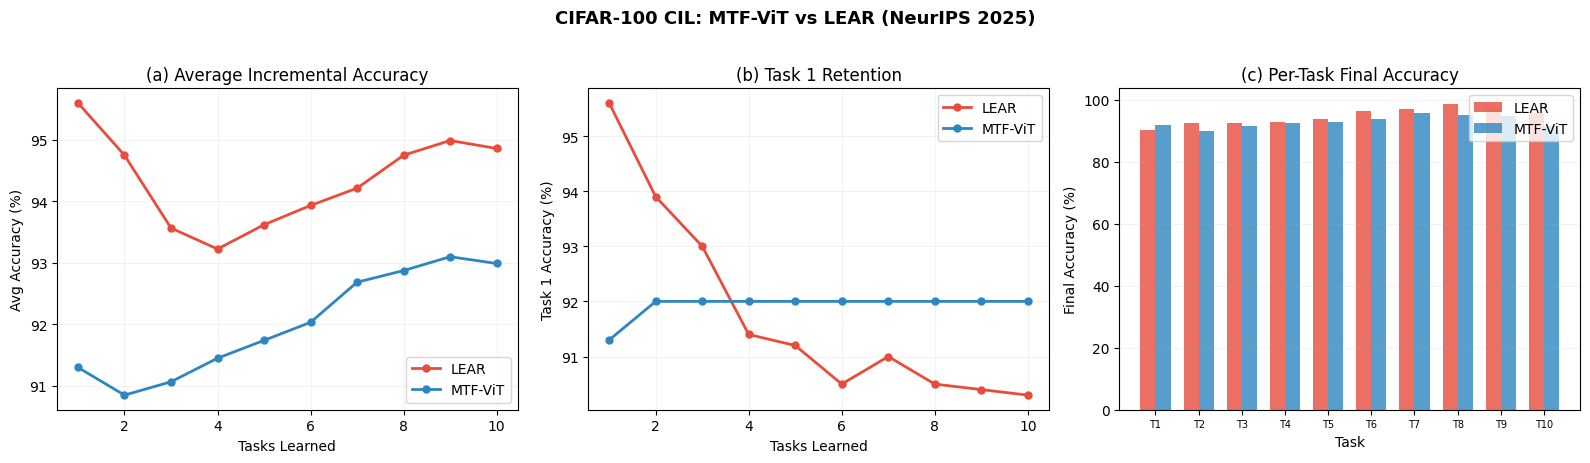

In [7]:
# ============================================================
# Cell 7: Compare Results
# ============================================================
import matplotlib.pyplot as plt

def cl_metrics(A, name):
    T = A.shape[0]
    avg_acc = A[:, -1].mean()
    bwt = sum(A[i,-1] - A[i,i] for i in range(T-1)) / (T-1)
    fgt = sum(max(A[i,j] for j in range(i,T)) - A[i,-1] for i in range(T-1)) / (T-1)
    return {'name': name, 'avg_acc': avg_acc, 'bwt': bwt, 'fgt': fgt}

results = {
    'LEAR': cl_metrics(A_lear, 'LEAR'),
    'MTF-ViT': cl_metrics(A_mtf, 'MTF-ViT'),
}

print('=' * 60)
print('CIFAR-100 CLASS-INCREMENTAL LEARNING RESULTS')
print(f'{N_TASKS} tasks x {CLS_PER_TASK} classes, {EPOCHS} epochs/task')
print('=' * 60)
print(f'{" ":15s} {"Avg Acc":>8s} {"BWT":>8s} {"Forget":>8s} {"Task Labels":>12s}')
print('-' * 55)
for name, m in results.items():
    tl = 'Yes' if name == 'LEAR' else 'No'
    print(f'{name:15s} {m["avg_acc"]:8.3f} {m["bwt"]:8.3f} {m["fgt"]:8.3f} {tl:>12s}')

# ── Plot ──
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
colors = {'LEAR': '#E74C3C', 'MTF-ViT': '#2E86C1'}

# Panel A: Average incremental accuracy
ax = axes[0]
for name, A in [('LEAR', A_lear), ('MTF-ViT', A_mtf)]:
    avg = [A[:t+1, t].mean()*100 for t in range(N_TASKS)]
    ax.plot(range(1, N_TASKS+1), avg, '-o', color=colors[name], lw=2, ms=5, label=name)
ax.set_xlabel('Tasks Learned'); ax.set_ylabel('Avg Accuracy (%)')
ax.set_title('(a) Average Incremental Accuracy')
ax.legend(); ax.grid(True, alpha=0.15)

# Panel B: Task 1 retention
ax = axes[1]
for name, A in [('LEAR', A_lear), ('MTF-ViT', A_mtf)]:
    t1 = [A[0, t]*100 for t in range(N_TASKS)]
    ax.plot(range(1, N_TASKS+1), t1, '-o', color=colors[name], lw=2, ms=5, label=name)
ax.set_xlabel('Tasks Learned'); ax.set_ylabel('Task 1 Accuracy (%)')
ax.set_title('(b) Task 1 Retention')
ax.legend(); ax.grid(True, alpha=0.15)

# Panel C: Per-task final accuracy
ax = axes[2]
x = np.arange(N_TASKS)
w = 0.35
for i, (name, A) in enumerate([('LEAR', A_lear), ('MTF-ViT', A_mtf)]):
    ax.bar(x + (i-0.5)*w, [A[t,-1]*100 for t in range(N_TASKS)], w,
           color=colors[name], label=name, alpha=0.8)
ax.set_xlabel('Task'); ax.set_ylabel('Final Accuracy (%)')
ax.set_title('(c) Per-Task Final Accuracy')
ax.set_xticks(x); ax.set_xticklabels([f'T{t+1}' for t in range(N_TASKS)], fontsize=7)
ax.legend(); ax.grid(True, alpha=0.15, axis='y')

fig.suptitle('CIFAR-100 CIL: MTF-ViT vs LEAR (NeurIPS 2025)', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('mtf_vs_lear.png', dpi=150, bbox_inches='tight')
plt.show()
